# Lead Scoring — X Education
### Predicting lead conversion likelihood to prioritize sales effort

**Problem:** X Education converts only ~30% of leads. The goal is to build a model that assigns
each lead a **score (0–100)** representing conversion likelihood, so the sales team can focus
on high-potential leads first and push conversion toward the 80% target.

**Dataset:** [Lead Scoring Dataset (Kaggle)](https://www.kaggle.com/datasets/amritachatterjee09/lead-scoring-dataset)

**Approach:** Logistic Regression compared against XGBoost. Final lead score = calibrated conversion probability × 100.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


## 1. Load Data

In [75]:
df = pd.read_csv("../dataset/LeadScoring.csv")
print("Shape:", df.shape)
df.head()


Shape: (9240, 37)


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [76]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   str    
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   str    
 3   Lead Source                                    9204 non-null   str    
 4   Do Not Email                                   9240 non-null   str    
 5   Do Not Call                                    9240 non-null   str    
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 non-null   

## 2. Data Cleaning

The dataset has a well-known quirk: many categorical fields use the literal string
`"Select"` as a placeholder for leads who didn't pick an option in the dropdown —
functionally a missing value, but not encoded as NaN. We treat it as such.


In [77]:
df = df.replace("Select", np.nan)

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]


How did you hear about X Education               78.463203
Lead Profile                                     74.188312
Lead Quality                                     51.590909
Asymmetrique Profile Index                       45.649351
Asymmetrique Activity Index                      45.649351
Asymmetrique Activity Score                      45.649351
Asymmetrique Profile Score                       45.649351
City                                             39.707792
Specialization                                   36.580087
Tags                                             36.287879
What matters most to you in choosing a course    29.318182
What is your current occupation                  29.112554
Country                                          26.634199
Page Views Per Visit                              1.482684
TotalVisits                                       1.482684
Last Activity                                     1.114719
Lead Source                                       0.3896

In [78]:
high_null_cols = missing_pct[missing_pct > 40].index.tolist()
print("Dropping (high null%):", high_null_cols)
df = df.drop(columns=high_null_cols)

id_cols = [c for c in ["Prospect ID", "Lead Number"] if c in df.columns]
df = df.drop(columns=id_cols)


Dropping (high null%): ['How did you hear about X Education', 'Lead Profile', 'Lead Quality', 'Asymmetrique Profile Index', 'Asymmetrique Activity Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']


In [79]:
low_variance_cols = []
for col in df.select_dtypes(include=["object", "string"]).columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq > 0.95:
        low_variance_cols.append(col)

print("Dropping (near-constant):", low_variance_cols)
df = df.drop(columns=low_variance_cols)


Dropping (near-constant): ['Do Not Call', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque']


In [80]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove("Converted")
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining nulls:", df.isnull().sum().sum())


Remaining nulls: 0


## 3. Exploratory Data Analysis

Overall conversion rate: 38.5%


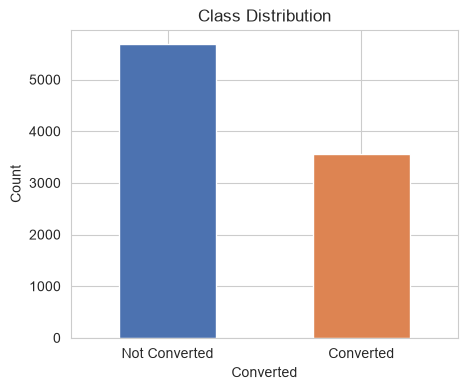

In [81]:
conv_rate = df["Converted"].mean() * 100
print(f"Overall conversion rate: {conv_rate:.1f}%")

plt.figure(figsize=(5,4))
df["Converted"].value_counts().plot(kind="bar", color=["#4C72B0","#DD8452"])
plt.xticks([0,1], ["Not Converted", "Converted"], rotation=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()


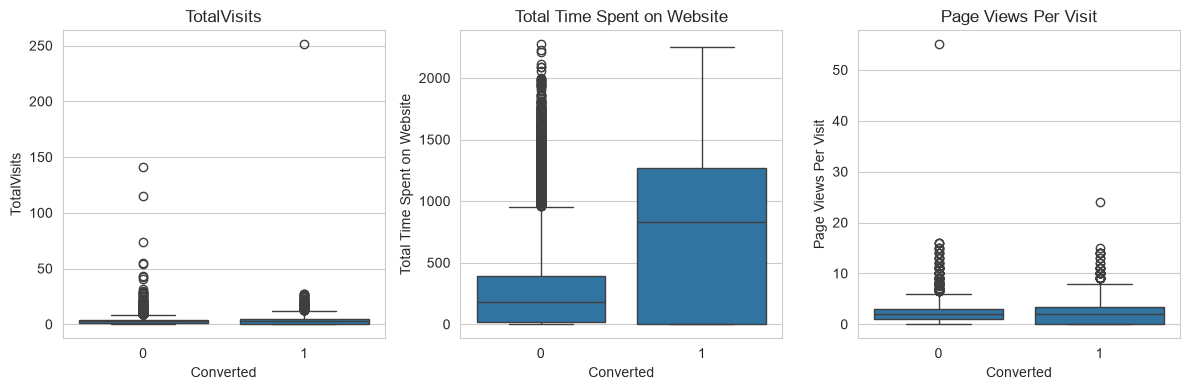

In [82]:
plt.figure(figsize=(12,4))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(x="Converted", y=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.show()


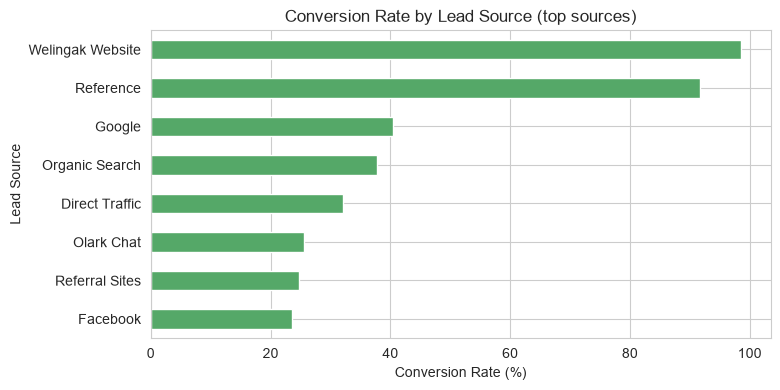

In [83]:
top_sources = df["Lead Source"].value_counts().nlargest(8).index
source_conv = df[df["Lead Source"].isin(top_sources)].groupby("Lead Source")["Converted"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8,4))
source_conv.plot(kind="barh", color="#55A868")
plt.xlabel("Conversion Rate (%)")
plt.title("Conversion Rate by Lead Source (top sources)")
plt.gca().invert_yaxis()
plt.show()


## 4. Feature Encoding

In [97]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
print(f"{len(cat_cols)} categorical columns to encode:", cat_cols)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)


12 categorical columns to encode: ['Lead Origin', 'Lead Source', 'Do Not Email', 'Last Activity', 'Country', 'Specialization', 'What is your current occupation', 'What matters most to you in choosing a course', 'Tags', 'City', 'A free copy of Mastering The Interview', 'Last Notable Activity']
Shape after encoding: (9240, 152)


## 5. Train/Test Split

In [85]:
X = df_encoded.drop(columns=["Converted"])
y = df_encoded["Converted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (7392, 151)  Test: (1848, 151)


## 6. Model 1 — Logistic Regression (Primary Model)

Chosen as the primary model because lead scoring needs to be **explainable** to a sales team —
coefficients map directly to "this factor increases/decreases conversion odds by X%", which
XGBoost's feature importances don't give as cleanly. `class_weight="balanced"` handles the
mild class imbalance (~38% conversion).


In [86]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.3f}")
print(f"F1:        {f1_score(y_test, y_pred_lr):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.3f}")


Logistic Regression Performance
Accuracy:  0.889
Precision: 0.847
Recall:    0.869
F1:        0.858
ROC-AUC:   0.948


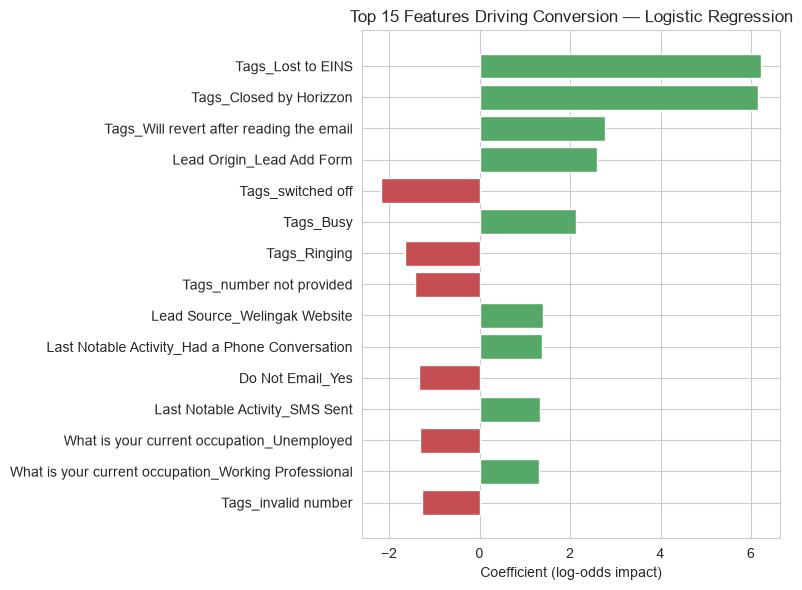

In [ ]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False).head(15)

plt.figure(figsize=(8,6))
colors = ["#55A868" if c > 0 else "#C44E52" for c in coef_df["coefficient"]]
plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
plt.xlabel("Coefficient (log-odds impact)")
plt.title("Top 15 Features Driving Conversion — Logistic Regression")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Model 2 — XGBoost (Performance Benchmark)

In [88]:
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss", random_state=RANDOM_STATE
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.3f}")
print(f"F1:        {f1_score(y_test, y_pred_xgb):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_xgb):.3f}")


XGBoost Performance
Accuracy:  0.900
Precision: 0.859
Recall:    0.885
F1:        0.872
ROC-AUC:   0.956


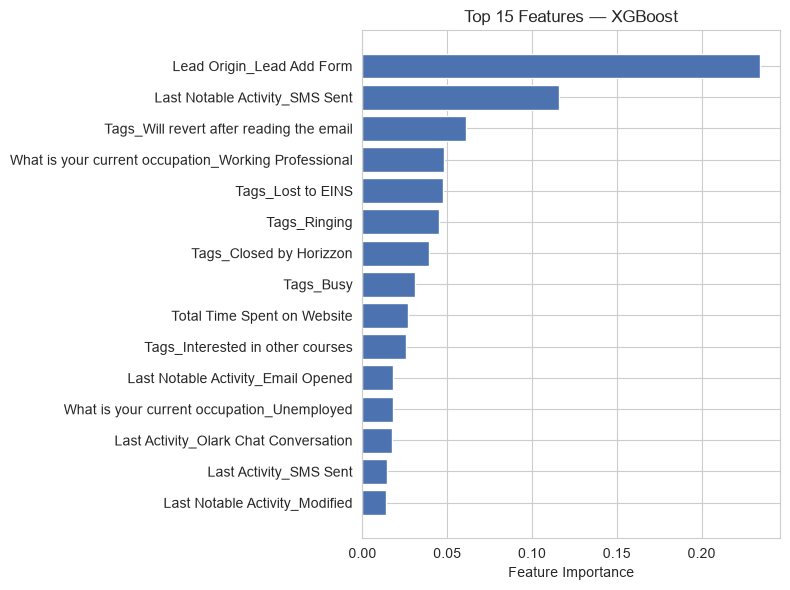

In [89]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
plt.barh(importances["feature"], importances["importance"], color="#4C72B0")
plt.xlabel("Feature Importance")
plt.title("Top 15 Features — XGBoost")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 8. Model Comparison

In [90]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_xgb)],
    "Precision": [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_xgb)],
    "Recall": [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_xgb)],
    "F1": [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_xgb)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_xgb)],
})
comparison


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.889069,0.846785,0.869382,0.857935,0.948049
1,XGBoost,0.899892,0.859482,0.884831,0.871972,0.955724


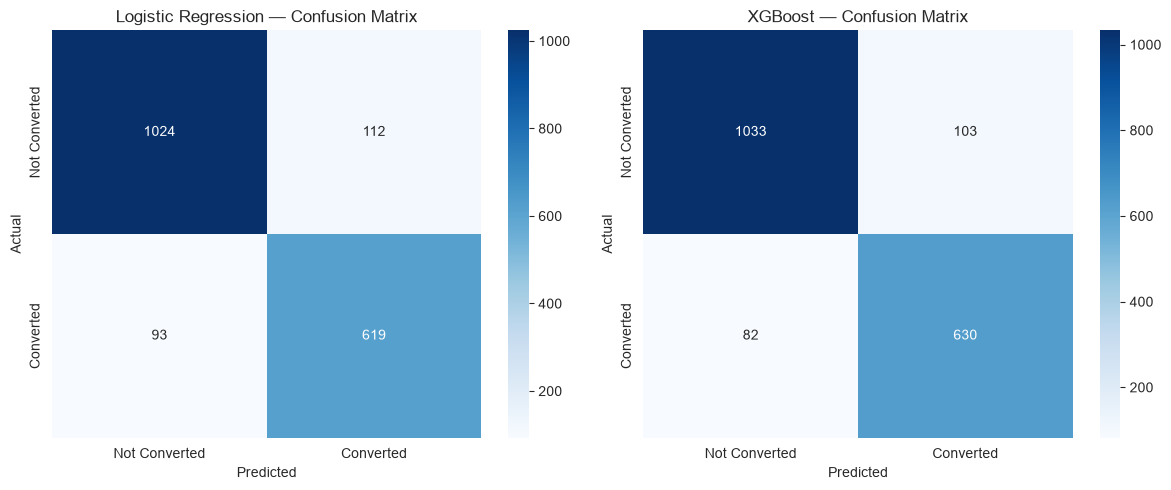

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for name, y_pred in [("Logistic Regression", y_pred_lr), ("XGBoost", y_pred_xgb)]:
    idx = 0 if name == "Logistic Regression" else 1
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                xticklabels=["Not Converted","Converted"], yticklabels=["Not Converted","Converted"])
    axes[idx].set_title(f"{name} — Confusion Matrix")
    axes[idx].set_ylabel("Actual")
    axes[idx].set_xlabel("Predicted")

plt.tight_layout()
plt.show()


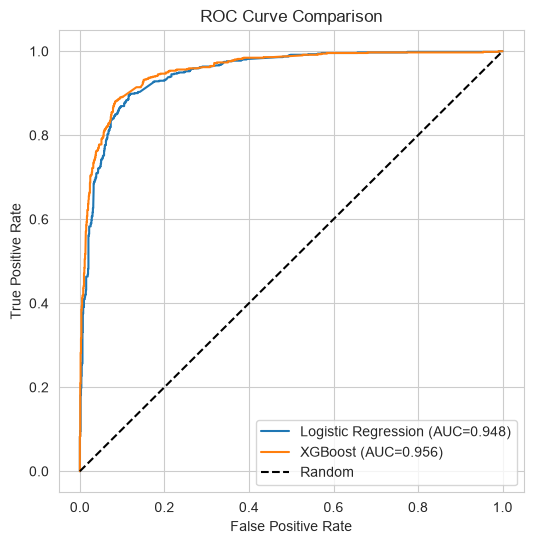

In [92]:
plt.figure(figsize=(6,6))
for name, y_proba in [("Logistic Regression", y_proba_lr), ("XGBoost", y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## 9. Lead Scoring

Convert predicted probabilities into a **0–100 lead score**, so the sales team gets an
intuitive ranking rather than raw probabilities. Using the Logistic Regression model
as the scoring model for interpretability.


In [93]:
lead_scores = pd.DataFrame({
    "actual_converted": y_test.values,
    "lead_score": (y_proba_lr * 100).round(1)
}).sort_values("lead_score", ascending=False).reset_index(drop=True)

lead_scores.head(10)


,actual_converted,lead_score
0,1,100.0
1,1,100.0
2,1,100.0
3,1,100.0
4,1,100.0
5,1,100.0
6,1,100.0
7,1,100.0
8,1,100.0
9,1,100.0


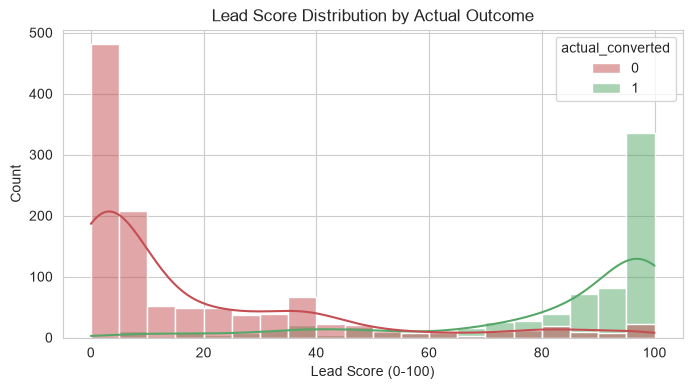

In [94]:
plt.figure(figsize=(8,4))
sns.histplot(data=lead_scores, x="lead_score", hue="actual_converted", bins=20, kde=True, palette=["#C44E52","#55A868"])
plt.title("Lead Score Distribution by Actual Outcome")
plt.xlabel("Lead Score (0-100)")
plt.show()


In [ ]:
lead_scores_sorted = lead_scores.sort_values("lead_score", ascending=False).reset_index(drop=True)
total_converters = lead_scores_sorted["actual_converted"].sum()

for pct in [10, 20, 30, 50]:
    n = int(len(lead_scores_sorted) * pct / 100)
    captured = lead_scores_sorted.head(n)["actual_converted"].sum()
    print(f"Top {pct}% of leads by score capture {captured/total_converters*100:.1f}% of all converters")


Top 10% of leads by score capture 25.0% of all converters
Top 20% of leads by score capture 48.6% of all converters
Top 30% of leads by score capture 71.1% of all converters
Top 50% of leads by score capture 94.5% of all converters


## 10. Save Models

In [96]:
import joblib
import os

os.makedirs("../data", exist_ok=True)

joblib.dump(log_reg, "../data/logistic_model.pkl")
joblib.dump(xgb_model, "../data/xgboost_model.pkl")
joblib.dump(scaler, "../data/scaler.pkl")
joblib.dump(list(X_train.columns), "../data/feature_columns.pkl")

df_encoded.to_csv("../data/processed_leads.csv", index=False)

print("Models and processed data saved to ../data/")


Models and processed data saved to ../data/


## 11. Conclusion

- **Logistic Regression** was selected as the primary scoring model for its interpretability — 
  sales teams can trust and act on a score when they understand what drives it.
- **XGBoost** was built as a benchmark; compare the metrics above to decide whether the accuracy 
  gain justifies losing interpretability for this use case.
- The lead score (0-100) lets the sales team prioritize outreach — the "top N% capture" analysis 
  above shows how much of the conversion opportunity is concentrated in the highest-scored leads, 
  directly supporting the goal of moving from 30% toward the 80% conversion target by focusing 
  effort where it counts.
